In [1]:
!pip install seaborn

In [2]:
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
from tqdm import tqdm

Cleaning datasets using autoencoder...

Processing class 0...


Class 0 Epoch 1, Total Loss: 32.6699


Class 0 Epoch 2, Total Loss: 19.6819


Class 0 Epoch 3, Total Loss: 17.8850


Class 0: removed 127 samples

Processing class 1...


...

Class 1: removed 8 samples

Processing class 2...


Class 2 Epoch 1, Total Loss: 4.0955


Class 2 Epoch 2, Total Loss: 4.1386


Class 2: removed 5 samples

Balancing train dataset...
Before balancing: {np.int64(0): np.int64(2403), np.int64(1): np.int64(1273), np.int64(2): np.int64(1277)}
After balancing: {np.int64(0): np.int64(1273), np.int64(1): np.int64(1273), np.int64(2): np.int64(1273)}
Classes: ['BACTERIAL_PNEUMONIA', 'NORMAL', 'VIRAL_PNEUMONIA']
Train size: 3819
Validation size: 186
Test size: 604


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0735948].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0177169].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0217083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0815775].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0775862].


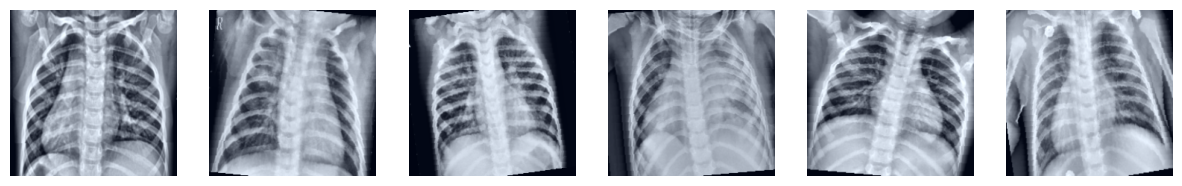

🔹 Train Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 1273 (33.33%)
NORMAL: 1273 (33.33%)
VIRAL_PNEUMONIA: 1273 (33.33%)

🔹 Test Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 234 (38.74%)
NORMAL: 227 (37.58%)
VIRAL_PNEUMONIA: 143 (23.68%)
🔹 Validation Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 62 (33.33%)
NORMAL: 62 (33.33%)
VIRAL_PNEUMONIA: 62 (33.33%)


In [3]:
import import_ipynb
import Preprocessing_Pipeline as prep

In [4]:
with open("classes.json", "r") as f:
    class_names = json.load(f)

num_classes = len(class_names)

In [5]:
def build_model(model_name, num_classes, pretrained=False):
    model_name = model_name.lower()
    if model_name == "resnet50":
        weights = (
            models.ResNet50_Weights.DEFAULT
            if pretrained else None
        )
        model = models.resnet50(
            weights=weights
        )
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.fc.in_features, num_classes)
        )
    elif model_name == "efficientnet":
        weights = (
            models.EfficientNet_B4_Weights.DEFAULT
            if pretrained else None
        )
        model = models.efficientnet_b4(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    
    elif model_name == "convnext":
        weights = (
            models.ConvNeXt_Base_Weights.DEFAULT
            if pretrained else None
        )
        model = models.convnext_base(weights=weights)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    else:
        raise ValueError(f"Unknown model name: {model_name}")
    return model

In [6]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_paths = {
    "ResNet50": "resnet50_pneumonia.pth",
    "EfficientNet-B4": "EfficientNet-B4_pneumonia.pth",
    "ConvNeXt": "ConvNeXt_pneumonia.pth"
}

models_dict = {}

for name, path in model_paths.items():
    clean_name = name.lower().split("-")[0]
    print(f"Loading {name} using architecture key: {clean_name}...")
    num_classes=3
    model = build_model(clean_name, num_classes)
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()
    models_dict[name] = model

print("\nModels successfully loaded:", list(models_dict.keys()))

Loading ResNet50 using architecture key: resnet50...
Loading EfficientNet-B4 using architecture key: efficientnet...
Loading ConvNeXt using architecture key: convnext...

Models successfully loaded: ['ResNet50', 'EfficientNet-B4', 'ConvNeXt']


In [7]:
def evaluate_model(model, loader):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(DEVICE)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

In [8]:
results = {}

for name, model in models_dict.items():
    print(f"\nEvaluating {name}...")

    y_true, y_pred = evaluate_model(model, prep.test_loader)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')

    results[name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "accuracy": acc,
        "f1": f1
    }

    print(f"{name} -> Accuracy: {acc:.4f}, F1: {f1:.4f}")


Evaluating ResNet50...


100%|██████████| 10/10 [00:27<00:00,  2.70s/it]


ResNet50 -> Accuracy: 0.8477, F1: 0.8511

Evaluating EfficientNet-B4...


100%|██████████| 10/10 [00:30<00:00,  3.07s/it]


EfficientNet-B4 -> Accuracy: 0.7947, F1: 0.7960

Evaluating ConvNeXt...


100%|██████████| 10/10 [00:29<00:00,  2.95s/it]

ConvNeXt -> Accuracy: 0.8675, F1: 0.8699


In [9]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

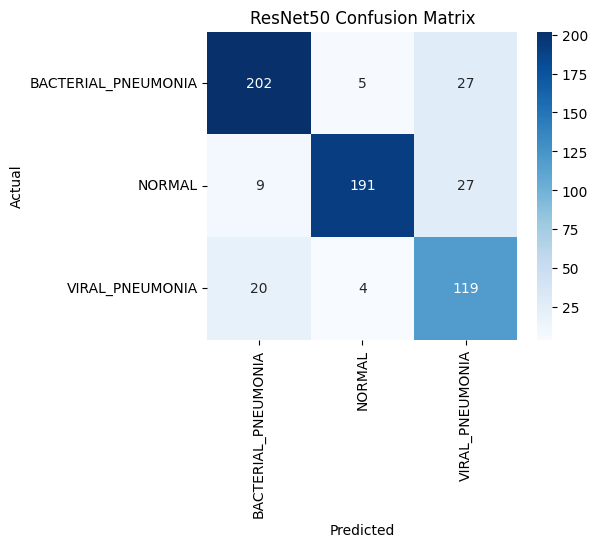

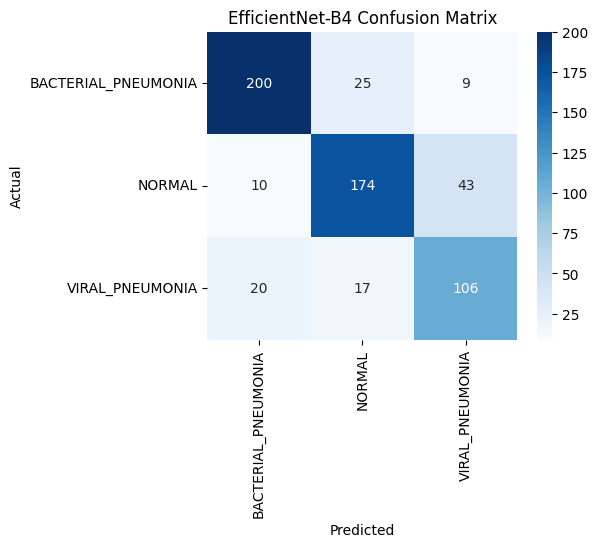

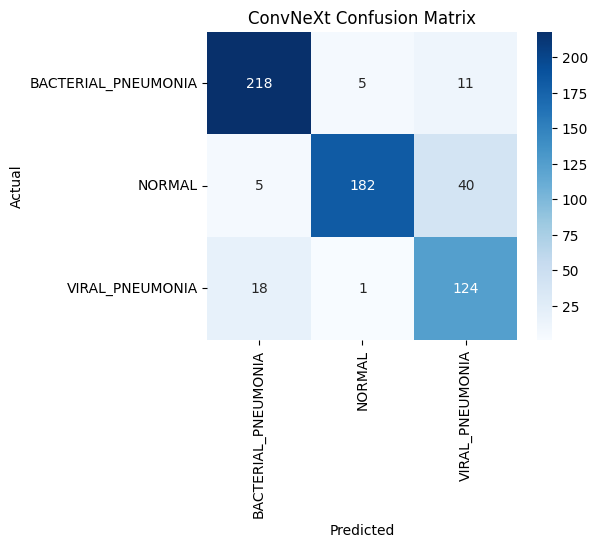

In [10]:
for name, res in results.items():
    plot_conf_matrix(res["y_true"], res["y_pred"], f"{name} Confusion Matrix")

In [11]:
for name, res in results.items():
    print(f"\n{name} Classification Report:\n")
    print(classification_report(res["y_true"], res["y_pred"], target_names=class_names))


ResNet50 Classification Report:

                     precision    recall  f1-score   support

BACTERIAL_PNEUMONIA       0.87      0.86      0.87       234
             NORMAL       0.95      0.84      0.89       227
    VIRAL_PNEUMONIA       0.69      0.83      0.75       143

           accuracy                           0.85       604
          macro avg       0.84      0.85      0.84       604
       weighted avg       0.86      0.85      0.85       604


EfficientNet-B4 Classification Report:

                     precision    recall  f1-score   support

BACTERIAL_PNEUMONIA       0.87      0.85      0.86       234
             NORMAL       0.81      0.77      0.79       227
    VIRAL_PNEUMONIA       0.67      0.74      0.70       143

           accuracy                           0.79       604
          macro avg       0.78      0.79      0.78       604
       weighted avg       0.80      0.79      0.80       604


ConvNeXt Classification Report:

                     precision 

In [12]:
import pandas as pd

comparison = []

for name, res in results.items():
    comparison.append({
        "Model": name,
        "Accuracy": res["accuracy"],
        "F1 Score": res["f1"]
    })

df = pd.DataFrame(comparison)
df = df.sort_values(by="F1 Score", ascending=False)

df

,Model,Accuracy,F1 Score
2,ConvNeXt,0.867550,0.869889
0,ResNet50,0.847682,0.851131
1,EfficientNet-B4,0.794702,0.795964


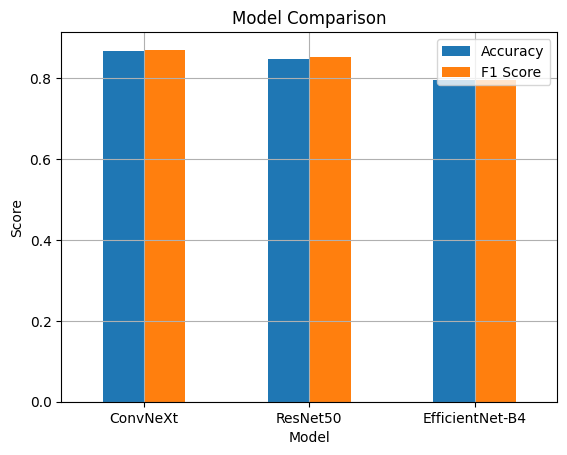

In [13]:
df.set_index("Model")[["Accuracy", "F1 Score"]].plot(kind="bar")
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid()
plt.show()